In [1]:
# =========================
# PART 1: Upload ZIP and Load Dataset
# =========================

from google.colab import files
import zipfile
import os
import pandas as pd

# Upload ZIP file
uploaded = files.upload()

# Get uploaded file name
zip_file = list(uploaded.keys())[0]
print("Uploaded file:", zip_file)

# Extract ZIP
extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP extracted successfully.")

# Find CSV file inside extracted folder
csv_file = None

for root, dirs, files_list in os.walk(extract_folder):
    for file in files_list:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

print("CSV file found:", csv_file)

# Load CSV
df = pd.read_csv(csv_file)

# Basic dataset information
print("Dataset loaded successfully.")
print("Rows and Columns:", df.shape)

# Show columns
print("\nColumns:")
print(df.columns)

# Show first 5 rows
df.head()

Saving fifa_eda_stats.csv.zip to fifa_eda_stats.csv.zip
Uploaded file: fifa_eda_stats.csv.zip
ZIP extracted successfully.
CSV file found: dataset/fifa_eda_stats.csv
Dataset loaded successfully.
Rows and Columns: (18207, 57)

Columns:
Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDiving', 'GK

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [2]:
df.shape

(18207, 57)

In [3]:
# =========================
# PART 2: Data Understanding
# =========================

# Show basic information
df.info()

# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("\nMissing values:")
print(missing_values[missing_values > 0])

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Show numerical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     18207 non-null  object 
 8   Wage                      18207 non-null  object 
 9   Preferred Foot            18159 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Weak Foot                 18159 non-null  float64
 12  Skill Moves               18159 non-null  float64
 13  Work Rate                 18159 non-null  object 
 14  Body T

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,18159.000000,18159.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,1.113222,2.947299,2.361308,19.546096,49.734181,45.550911,...,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,29965.244204,4.669943,6.908930,6.136496,0.394031,0.660456,0.756164,15.947765,18.364524,19.525820,...,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,16.000000,16.000000,46.000000,48.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,200315.500000,21.000000,62.000000,67.000000,1.000000,3.000000,2.000000,8.000000,38.000000,30.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,221759.000000,25.000000,66.000000,71.000000,1.000000,3.000000,2.000000,17.000000,54.000000,49.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,236529.500000,28.000000,71.000000,75.000000,1.000000,3.000000,3.000000,26.000000,64.000000,62.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,246620.000000,45.000000,94.000000,95.000000,5.000000,5.000000,5.000000,99.000000,93.000000,95.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


In [4]:
# Show all column names clearly
for i, col in enumerate(df.columns):
    print(i, col)

0 ID
1 Name
2 Age
3 Nationality
4 Overall
5 Potential
6 Club
7 Value
8 Wage
9 Preferred Foot
10 International Reputation
11 Weak Foot
12 Skill Moves
13 Work Rate
14 Body Type
15 Position
16 Jersey Number
17 Joined
18 Loaned From
19 Contract Valid Until
20 Height
21 Weight
22 Crossing
23 Finishing
24 HeadingAccuracy
25 ShortPassing
26 Volleys
27 Dribbling
28 Curve
29 FKAccuracy
30 LongPassing
31 BallControl
32 Acceleration
33 SprintSpeed
34 Agility
35 Reactions
36 Balance
37 ShotPower
38 Jumping
39 Stamina
40 Strength
41 LongShots
42 Aggression
43 Interceptions
44 Positioning
45 Vision
46 Penalties
47 Composure
48 Marking
49 StandingTackle
50 SlidingTackle
51 GKDiving
52 GKHandling
53 GKKicking
54 GKPositioning
55 GKReflexes
56 Release Clause


In [5]:
# =========================
# PART 3: Data Cleaning
# =========================

import numpy as np

# Remove duplicates
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

# -------------------------
# Function to clean money columns
# -------------------------

def clean_money(x):
    if pd.isnull(x):
        return np.nan

    x = str(x).replace('€', '')

    if 'M' in x:
        return float(x.replace('M', '')) * 1000000

    elif 'K' in x:
        return float(x.replace('K', '')) * 1000

    else:
        try:
            return float(x)
        except:
            return np.nan

# Clean money columns
money_columns = ['Value', 'Wage', 'Release Clause']

for col in money_columns:
    df[col] = df[col].apply(clean_money)

print("Money columns cleaned.")

# -------------------------
# Clean Height
# -------------------------

def convert_height(height):
    try:
        feet, inches = height.split("'")
        return (int(feet) * 12) + int(inches)
    except:
        return np.nan

df['Height'] = df['Height'].apply(convert_height)

# -------------------------
# Clean Weight
# -------------------------

df['Weight'] = df['Weight'].str.replace('lbs', '')
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# -------------------------
# Fill Missing Values
# -------------------------

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")

# Final check
print("\nRemaining missing values:")
print(df.isnull().sum().sum())

# Preview cleaned data
df.head()

Dataset shape after removing duplicates: (18207, 57)
Money columns cleaned.
Missing values handled.

Remaining missing values:
0


/tmp/ipykernel_10367/1854319085.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_10367/1854319085.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0


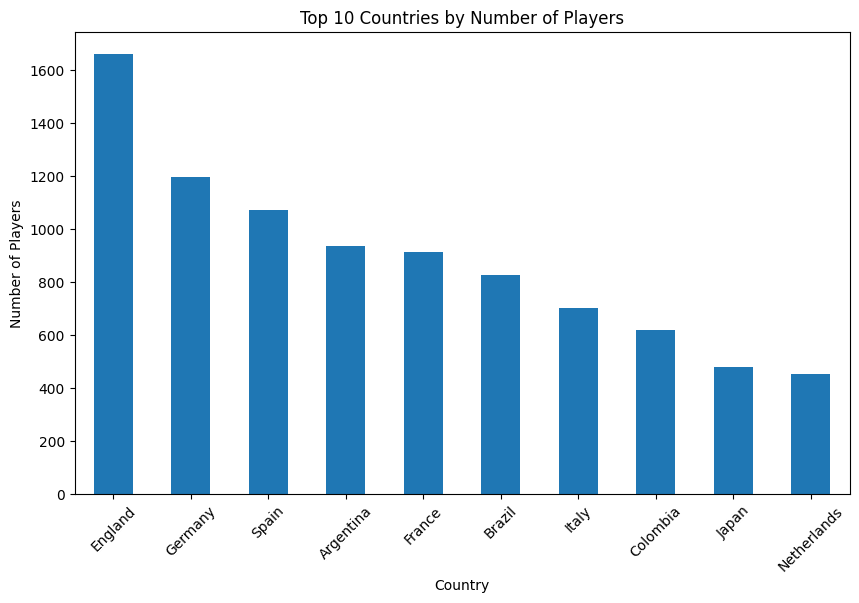

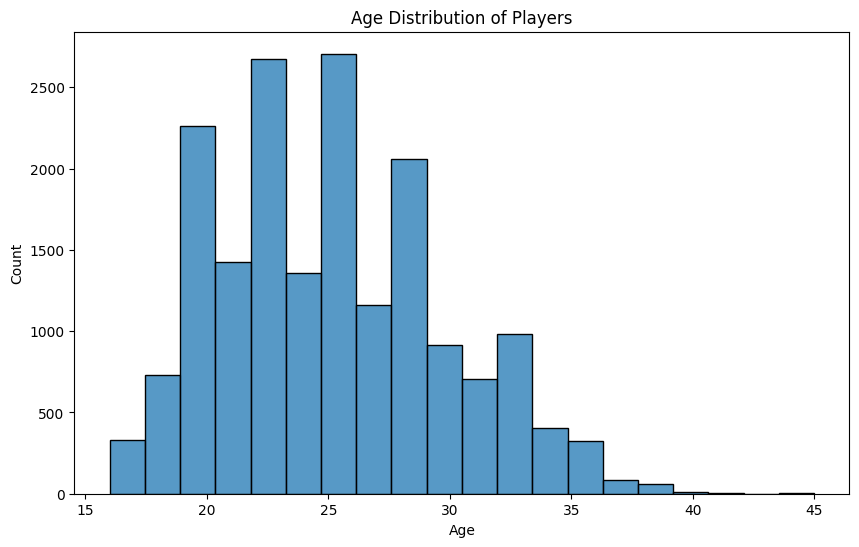

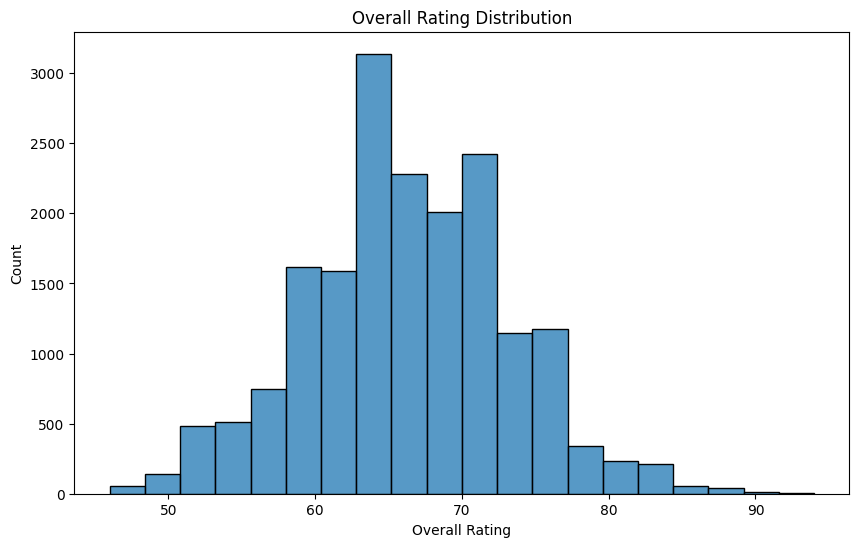

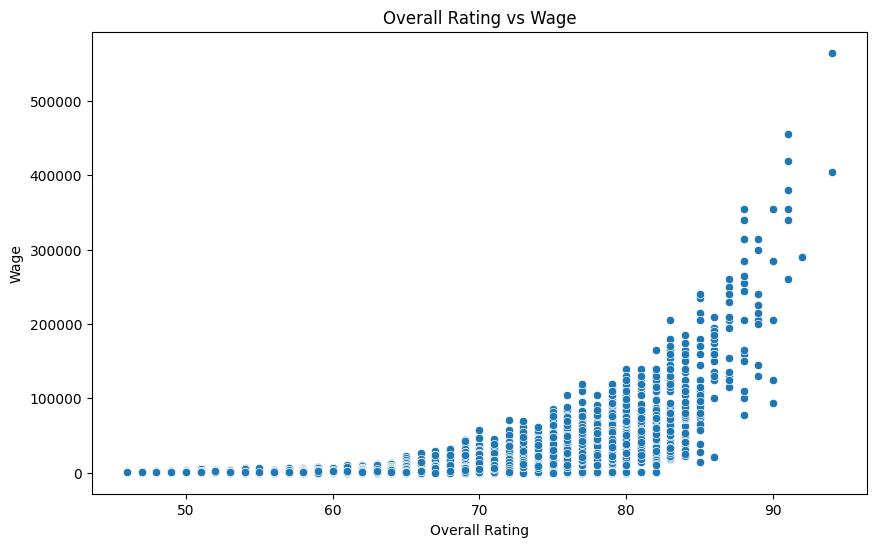

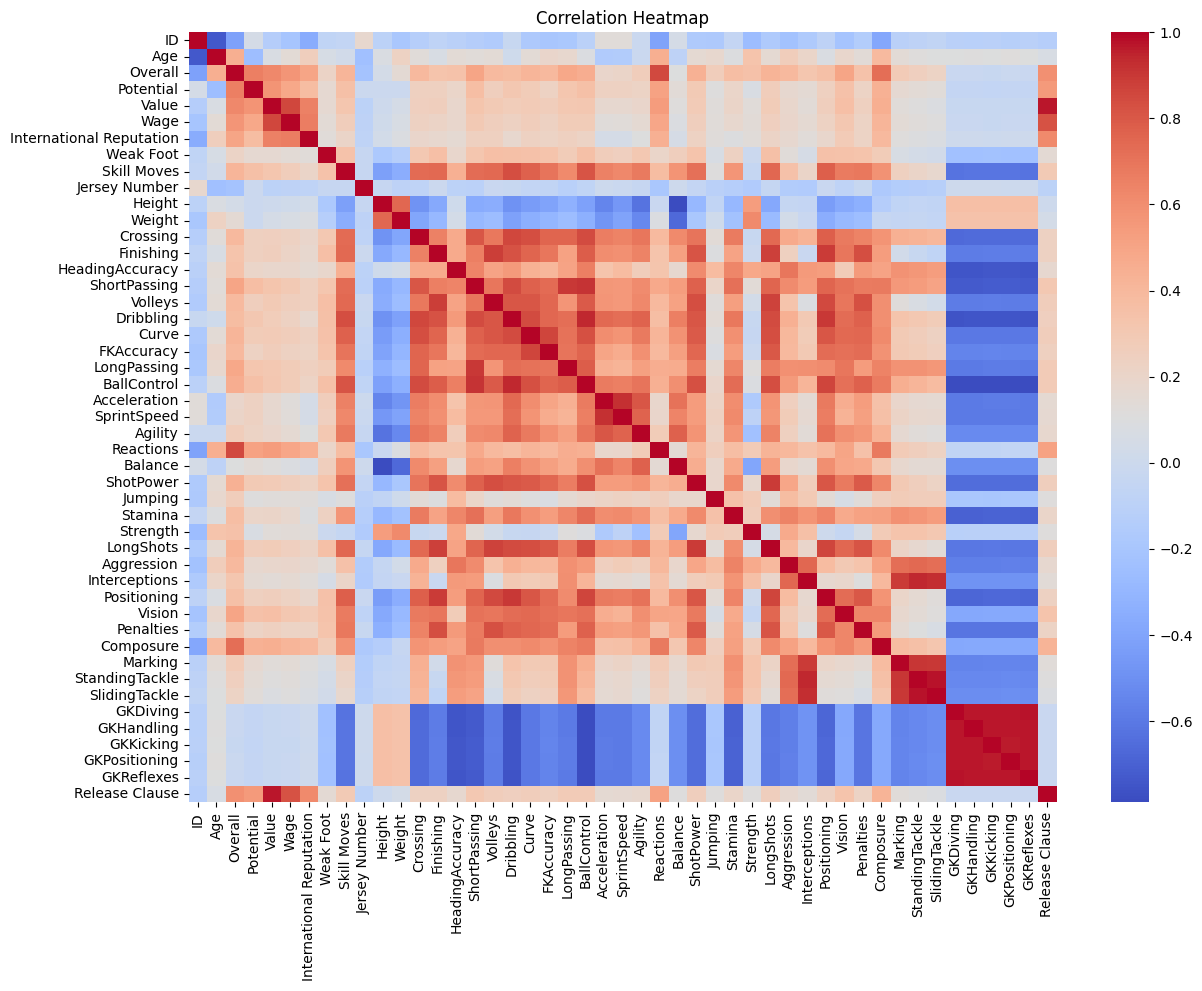

In [6]:
# =========================
# PART 4: Exploratory Data Analysis
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot size
plt.rcParams['figure.figsize'] = (10,6)

# -------------------------
# Top 10 Countries by Players
# -------------------------

top_countries = df['Nationality'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Number of Players')
plt.xlabel('Country')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Age Distribution
# -------------------------

plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution of Players')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# -------------------------
# Overall Rating Distribution
# -------------------------

plt.figure()
sns.histplot(df['Overall'], bins=20)
plt.title('Overall Rating Distribution')
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.show()

# -------------------------
# Wage vs Overall Rating
# -------------------------

plt.figure()
sns.scatterplot(x='Overall', y='Wage', data=df)
plt.title('Overall Rating vs Wage')
plt.xlabel('Overall Rating')
plt.ylabel('Wage')
plt.show()

# -------------------------
# Correlation Heatmap
# -------------------------

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
# =========================
# PART 5: Feature Selection and Encoding
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -------------------------
# Select important columns
# -------------------------

selected_columns = [
    'Age',
    'Overall',
    'Potential',
    'Wage',
    'International Reputation',
    'Weak Foot',
    'Skill Moves',
    'Height',
    'Weight',
    'Crossing',
    'Finishing',
    'HeadingAccuracy',
    'ShortPassing',
    'Dribbling',
    'Curve',
    'FKAccuracy',
    'LongPassing',
    'BallControl',
    'Acceleration',
    'SprintSpeed',
    'Agility',
    'Reactions',
    'Balance',
    'ShotPower',
    'Stamina',
    'Strength',
    'LongShots',
    'Aggression',
    'Interceptions',
    'Positioning',
    'Vision',
    'Penalties',
    'Composure',
    'Marking',
    'StandingTackle',
    'SlidingTackle',
    'GKDiving',
    'GKHandling',
    'GKKicking',
    'GKPositioning',
    'GKReflexes',
    'Preferred Foot',
    'Position'
]

# Create new dataframe
model_df = df[selected_columns + ['Value']]

# -------------------------
# Encode categorical columns
# -------------------------

label_encoder = LabelEncoder()

model_df['Preferred Foot'] = label_encoder.fit_transform(model_df['Preferred Foot'])

model_df['Position'] = label_encoder.fit_transform(model_df['Position'])

print("Categorical columns encoded.")

# -------------------------
# Features and target
# -------------------------

X = model_df.drop('Value', axis=1)

y = model_df['Value']

# -------------------------
# Train Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Categorical columns encoded.
Training data shape: (14565, 43)
Testing data shape: (3642, 43)


/tmp/ipykernel_10367/3684059915.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['Preferred Foot'] = label_encoder.fit_transform(model_df['Preferred Foot'])
/tmp/ipykernel_10367/3684059915.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['Position'] = label_encoder.fit_transform(model_df['Position'])


In [8]:
# =========================
# PART 6: Train 4 ML Models
# =========================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# -------------------------
# Create models
# -------------------------

lr_model = LinearRegression()

dt_model = DecisionTreeRegressor(
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    random_state=42
)

# -------------------------
# Train models
# -------------------------

print("Training Linear Regression...")
lr_model.fit(X_train, y_train)

print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

print("\nAll models trained successfully.")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [9]:
# =========================
# PART 7: Model Evaluation
# =========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

# -------------------------
# Predictions
# -------------------------

lr_pred = lr_model.predict(X_test)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

# -------------------------
# Function to evaluate model
# -------------------------

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

# -------------------------
# Evaluate all models
# -------------------------

results = []

results.append(
    evaluate_model(y_test, lr_pred, "Linear Regression")
)

results.append(
    evaluate_model(y_test, dt_pred, "Decision Tree")
)

results.append(
    evaluate_model(y_test, rf_pred, "Random Forest")
)

results.append(
    evaluate_model(y_test, gb_pred, "Gradient Boosting")
)

# -------------------------
# Create results dataframe
# -------------------------

results_df = pd.DataFrame(results)

# Show results
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.281482e+06,5.134828e+12,2.266016e+06,0.829585
1,Decision Tree,1.824526e+05,1.129052e+12,1.062568e+06,0.962529
2,Random Forest,1.349237e+05,6.049554e+11,7.777888e+05,0.979923
3,Gradient Boosting,2.138361e+05,4.542085e+11,6.739499e+05,0.984926


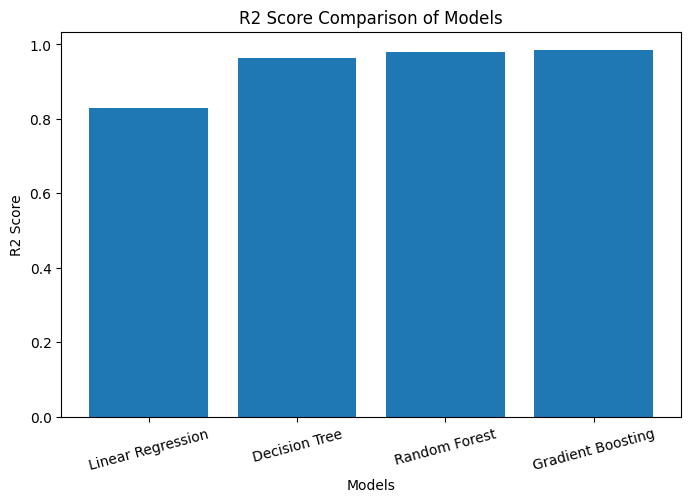

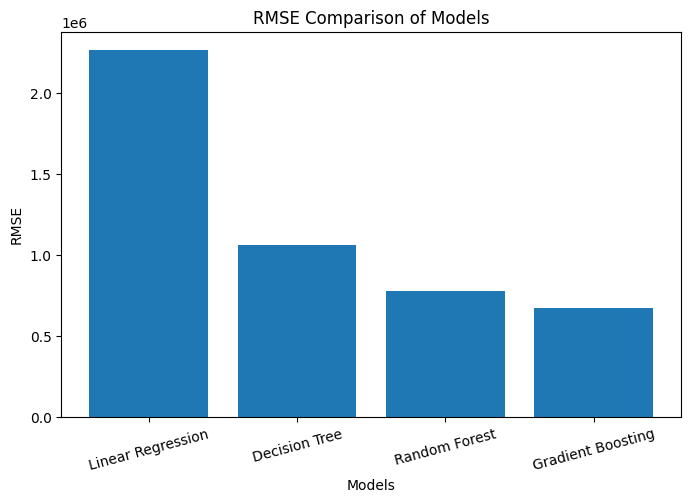

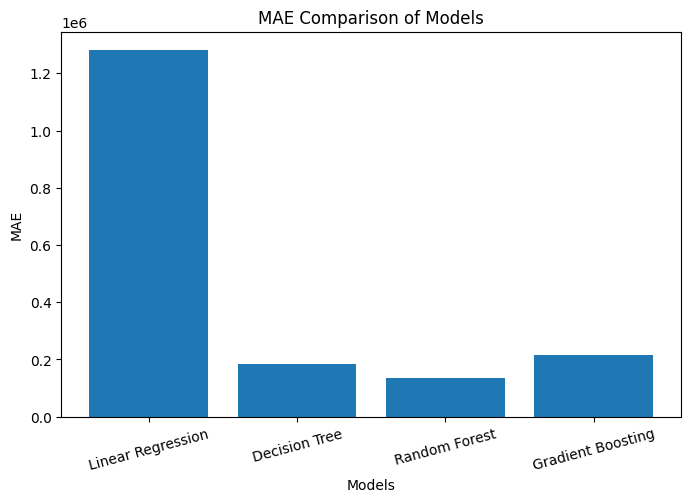

In [10]:
# =========================
# PART 8: Model Comparison Visualization
# =========================

import matplotlib.pyplot as plt

# -------------------------
# R2 Score Comparison
# -------------------------

plt.figure(figsize=(8,5))

plt.bar(results_df['Model'], results_df['R2 Score'])

plt.title('R2 Score Comparison of Models')

plt.xlabel('Models')

plt.ylabel('R2 Score')

plt.xticks(rotation=15)

plt.show()

# -------------------------
# RMSE Comparison
# -------------------------

plt.figure(figsize=(8,5))

plt.bar(results_df['Model'], results_df['RMSE'])

plt.title('RMSE Comparison of Models')

plt.xlabel('Models')

plt.ylabel('RMSE')

plt.xticks(rotation=15)

plt.show()

# -------------------------
# MAE Comparison
# -------------------------

plt.figure(figsize=(8,5))

plt.bar(results_df['Model'], results_df['MAE'])

plt.title('MAE Comparison of Models')

plt.xlabel('Models')

plt.ylabel('MAE')

plt.xticks(rotation=15)

plt.show()

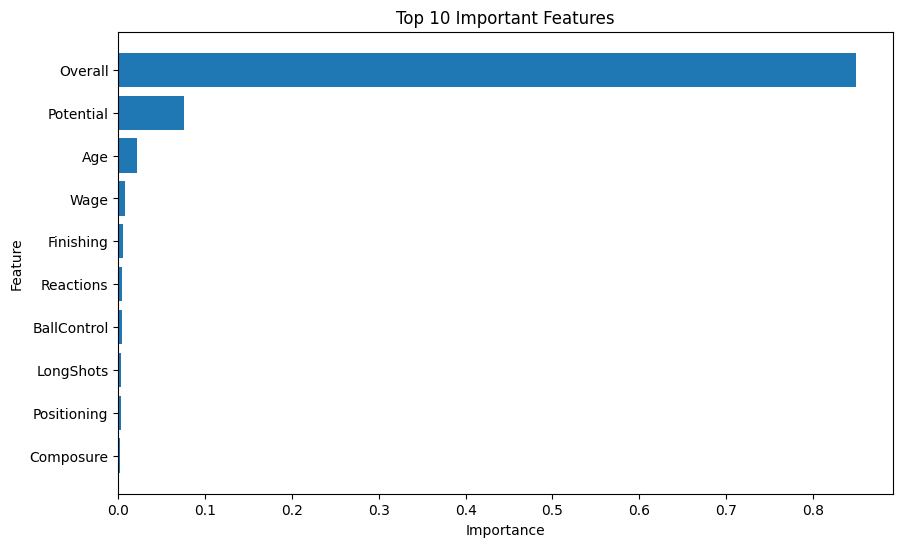

,Feature,Importance
1,Overall,0.849917
2,Potential,0.075206
0,Age,0.021335
3,Wage,0.007658
10,Finishing,0.005819
21,Reactions,0.004666
17,BallControl,0.004154
26,LongShots,0.003015
29,Positioning,0.002866
32,Composure,0.001982


In [11]:
# =========================
# PART 9: Feature Importance
# =========================

# Feature importance from Random Forest

importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top_features = feature_importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.show()

# Show table
top_features

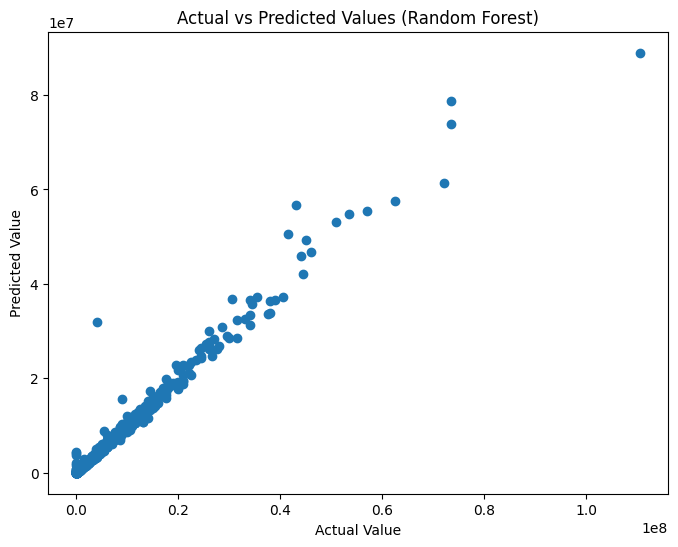

In [12]:
# =========================
# PART 10: Actual vs Predicted Graph
# =========================

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Value")

plt.ylabel("Predicted Value")

plt.title("Actual vs Predicted Values (Random Forest)")

plt.show()